<a href="https://colab.research.google.com/github/SUSHMASURE11/Predictive-Analytics/blob/Customer_Churn_Prediction/Customer_Churn_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Best Parameters: {'classifier__max_depth': None, 'classifier__n_estimators': 200}
Accuracy: 1.0

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00       206
           1       1.00      1.00      1.00        94

    accuracy                           1.00       300
   macro avg       1.00      1.00      1.00       300
weighted avg       1.00      1.00      1.00       300



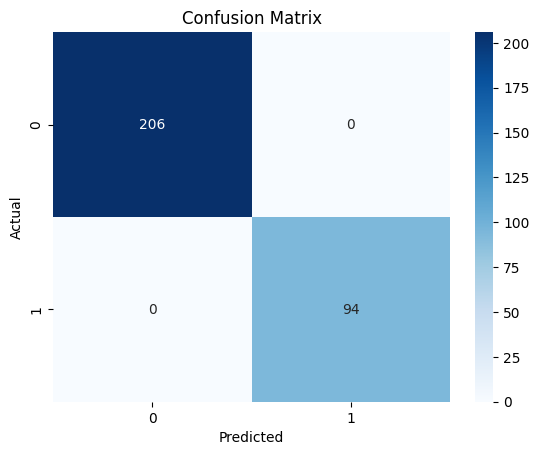


New Customer Prediction: Churn


In [1]:
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Generate Synthetic Dataset
np.random.seed(42)
n = 1500

data = pd.DataFrame({
    'Gender': np.random.choice(['Male', 'Female'], n),
    'Age': np.random.randint(18, 70, n),
    'Tenure': np.random.randint(0, 11, n),
    'Balance': np.random.uniform(0, 250000, n),
    'NumOfProducts': np.random.randint(1, 5, n),
    'HasCrCard': np.random.choice([0, 1], n),
    'IsActiveMember': np.random.choice([0, 1], n),
    'EstimatedSalary': np.random.uniform(20000, 200000, n),
    'Contract': np.random.choice(['Month-to-month', 'One year', 'Two year'], n),
    'InternetService': np.random.choice(['DSL', 'Fiber optic', 'No'], n),
    'TechSupport': np.random.choice(['Yes', 'No'], n),
    'StreamingTV': np.random.choice(['Yes', 'No'], n)
})

# 2. Define Target Variable (Churn) with Logic
data['Churn'] = (
    ((data['Contract'] == 'Month-to-month') &
     (data['IsActiveMember'] == 0) &
     (data['Balance'] < 50000)) |
    ((data['TechSupport'] == 'No') &
     (data['StreamingTV'] == 'Yes'))
).astype(int)

# 3. Preprocessing
features = data.drop("Churn", axis=1)
labels = data["Churn"]

# Define column types
num_features = ['Age', 'Tenure', 'Balance', 'EstimatedSalary', 'NumOfProducts']
cat_features = ['Gender', 'HasCrCard', 'IsActiveMember', 'Contract', 'InternetService', 'TechSupport', 'StreamingTV']

# 4. Pipeline: Preprocessing + Model
preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(), num_features),
    ('cat', OneHotEncoder(), cat_features)
])

model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(random_state=42))
])

# 5. Hyperparameter Tuning
param_grid = {
    'classifier__n_estimators': [100, 200],
    'classifier__max_depth': [None, 10, 20]
}

grid = GridSearchCV(model, param_grid, cv=5)
grid.fit(features, labels)

# 6. Evaluation
X_train, X_test, y_train, y_test = train_test_split(features, labels, test_size=0.2, random_state=42)
best_model = grid.best_estimator_
best_model.fit(X_train, y_train)
y_pred = best_model.predict(X_test)

print("Best Parameters:", grid.best_params_)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# 7. Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# 8. Predict New Customer
new_customer = pd.DataFrame([{
    'Gender': 'Female',
    'Age': 33,
    'Tenure': 1,
    'Balance': 20000,
    'NumOfProducts': 1,
    'HasCrCard': 1,
    'IsActiveMember': 0,
    'EstimatedSalary': 50000,
    'Contract': 'Month-to-month',
    'InternetService': 'Fiber optic',
    'TechSupport': 'No',
    'StreamingTV': 'Yes'
}])

prediction = best_model.predict(new_customer)[0]
print("\nNew Customer Prediction:", "Churn" if prediction == 1 else "Stay")
